# Bank Transaction and Fraud Detection Analysis

## Data Loading & Initial Inspection

In [ ]:
#import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import make_scorer
from sklearn.covariance import MinCovDet
import shap
import xgboost as xgb
import datetime
from scipy import stats
import warnings

# Optimization: Global config for performance
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
pd.options.display.max_columns = None

# Use all available CPU cores for supported models
N_JOBS = -1

In [ ]:


#Load local CSV
df = pd.read_csv("/bank_transactions_data_2.csv")

print(df.shape)
df.head()

(2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99


In [ ]:
# Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})
missing_df

,Missing Values,Percentage
TransactionID,0,0.0
AccountID,0,0.0
TransactionAmount,0,0.0
TransactionDate,0,0.0
TransactionType,0,0.0
Location,0,0.0
DeviceID,0,0.0
IP Address,0,0.0
MerchantID,0,0.0
Channel,0,0.0


In [ ]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Column type separation and Vectorized datetime processing
id_cols = ['TransactionID', 'AccountID']
date_cols = ['TransactionDate', 'PreviousTransactionDate']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')

# Memory Optimization: Downcasting types for faster processing
def optimize_types(df):
    floats = df.select_dtypes(include=['float64']).columns
    df[floats] = df[floats].apply(pd.to_numeric, downcast='float')
    ints = df.select_dtypes(include=['int64']).columns
    df[ints] = df[ints].apply(pd.to_numeric, downcast='integer')
    return df

df = optimize_types(df)
df.shape

(2512, 16)

In [ ]:
# Identify numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
Categorical columns: ['TransactionID', 'AccountID', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation']


## Exploratory Data Analysis (EDA)


### Univariate Analysis (Numerical Features)

For each numeric feature:

- Histogram + KDE (distribution shape).

- Boxplot (outliers).

- Summary stats (mean, std, min/max, skewness).

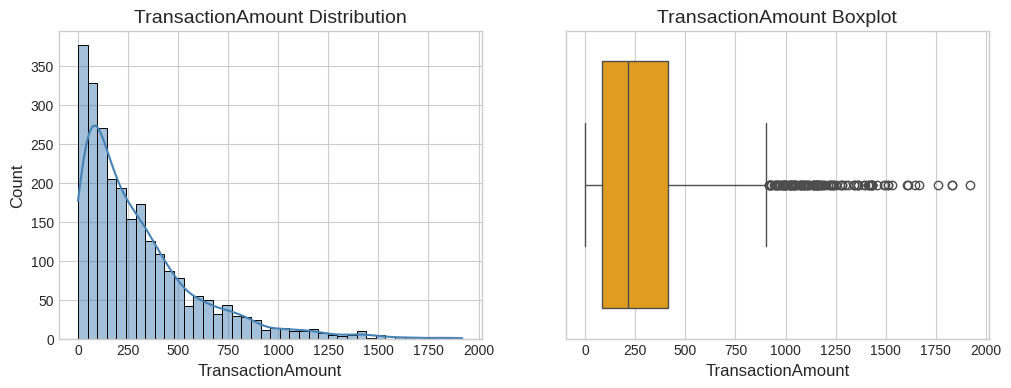

count    2512.000000
mean      297.593781
std       291.946381
min         0.260000
25%        81.885002
50%       211.139999
75%       414.527496
max      1919.109985
Name: TransactionAmount, dtype: float64
Skewness: 1.74, Kurtosis: 3.64



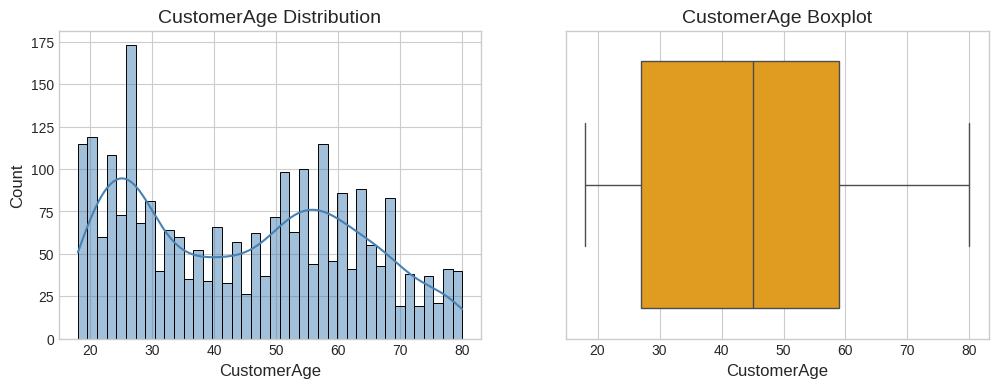

count    2512.000000
mean       44.673965
std        17.792198
min        18.000000
25%        27.000000
50%        45.000000
75%        59.000000
max        80.000000
Name: CustomerAge, dtype: float64
Skewness: 0.15, Kurtosis: -1.22



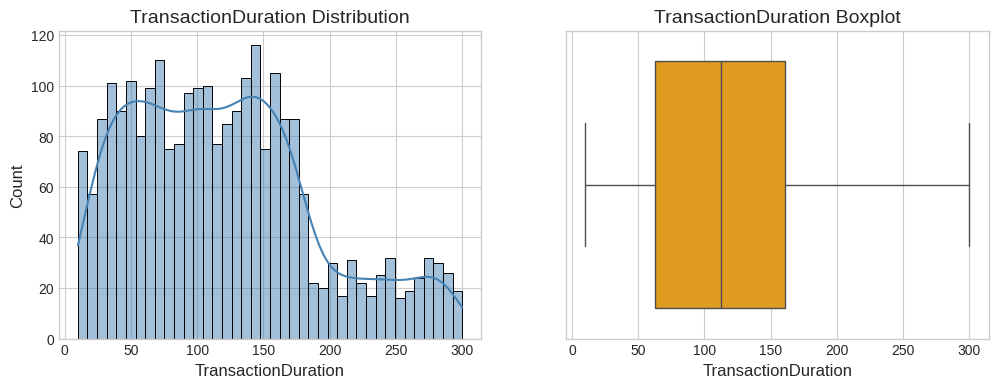

count    2512.000000
mean      119.643312
std        69.963757
min        10.000000
25%        63.000000
50%       112.500000
75%       161.000000
max       300.000000
Name: TransactionDuration, dtype: float64
Skewness: 0.60, Kurtosis: -0.26



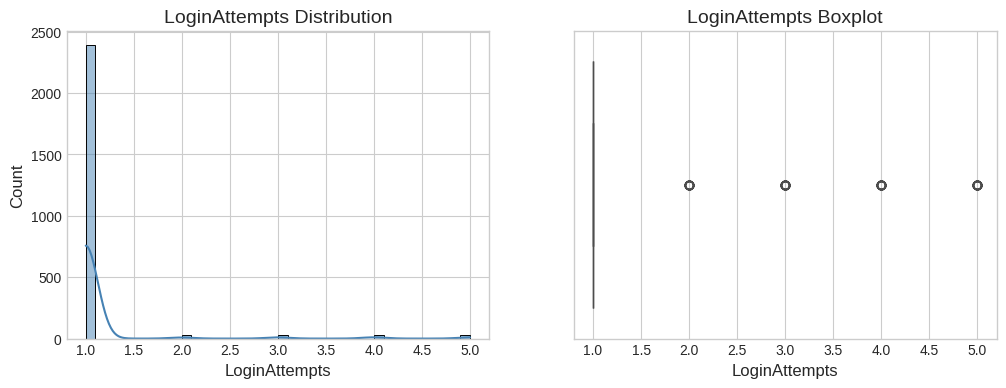

count    2512.000000
mean        1.124602
std         0.602662
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: LoginAttempts, dtype: float64
Skewness: 5.17, Kurtosis: 26.67



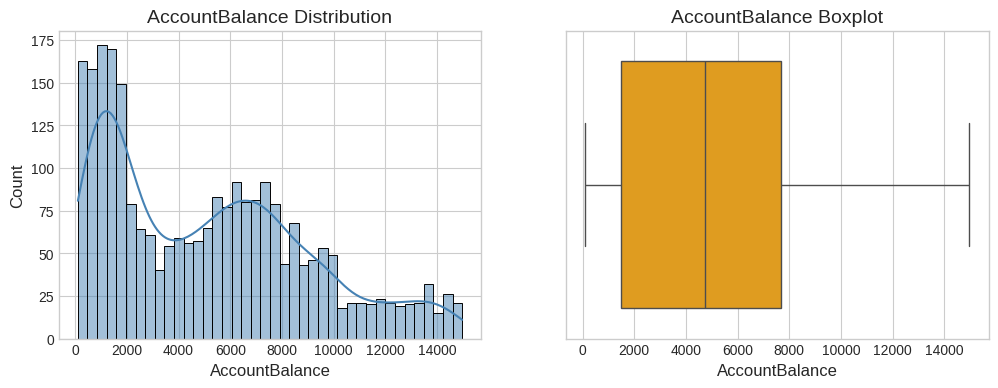

count     2512.000000
mean      5114.302734
std       3900.941406
min        101.250000
25%       1504.370026
50%       4735.510010
75%       7678.819824
max      14977.990234
Name: AccountBalance, dtype: float64
Skewness: 0.60, Kurtosis: -0.56



In [ ]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(df[col], kde=True, bins=40, ax=axes[0], color="steelblue")
    axes[0].set_title(f"{col} Distribution")
    sns.boxplot(x=df[col], ax=axes[1], color="orange")
    axes[1].set_title(f"{col} Boxplot")
    plt.show()
    print(df[col].describe().T)
    print(f"Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}\n")

### Univariate Analysis (Categorical Features)
This section explores categorical features by plotting their frequency distributions (e.g., TransactionType, Channel, Location, CustomerOccupation, DeviceID).

The goal is to understand the dominant categories and highlight rare values, which can be crucial indicators of unusual or potentially fraudulent behavior.

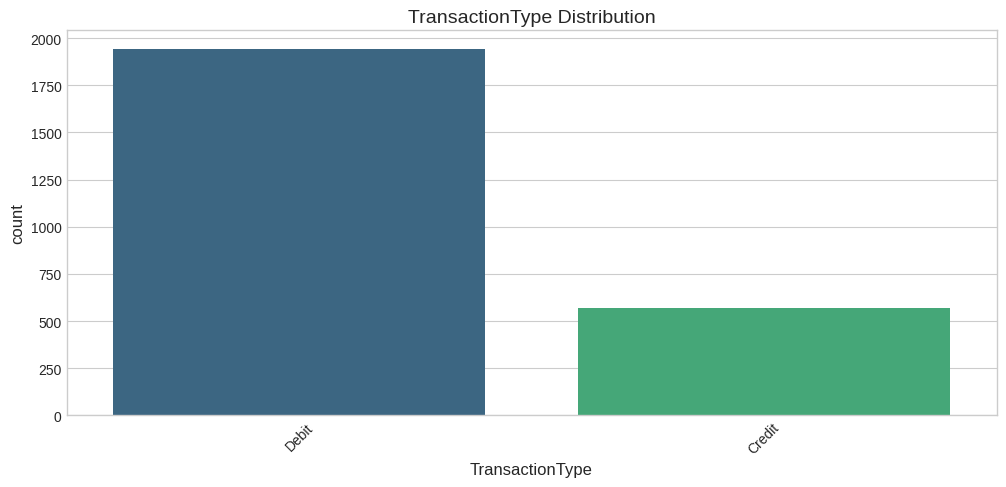

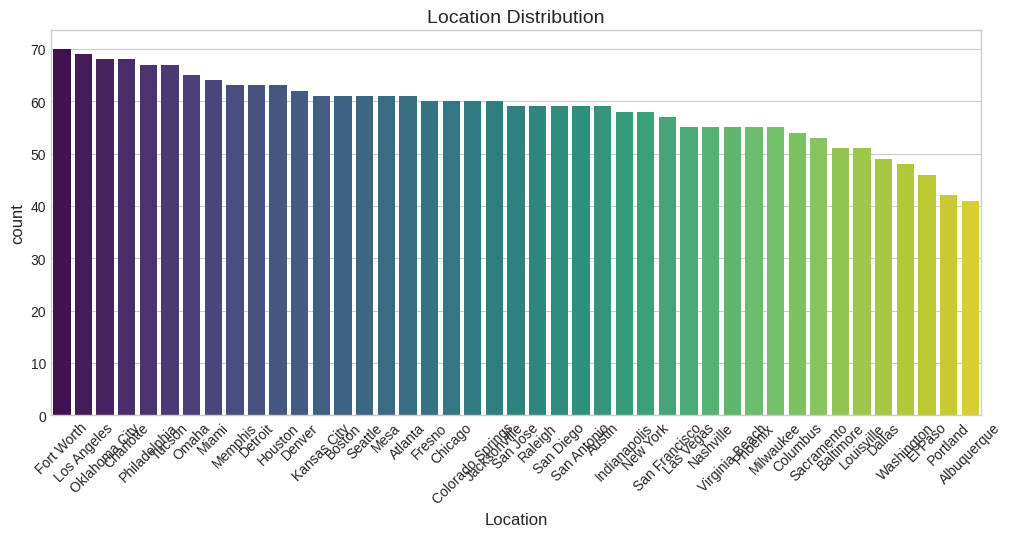

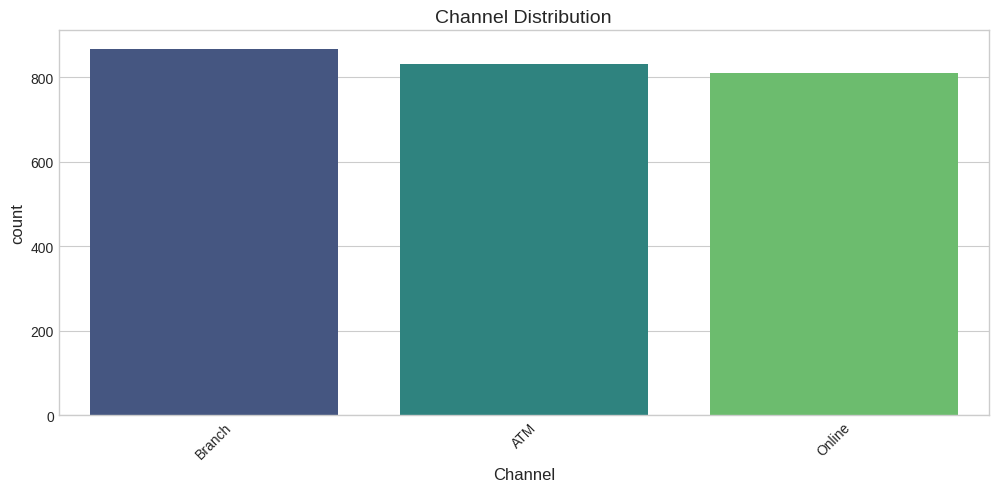

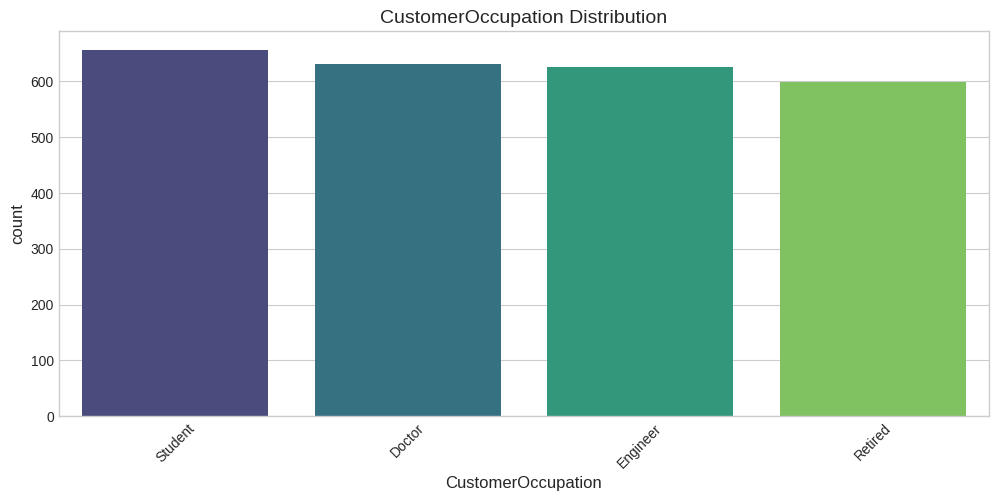

In [ ]:
cat_cols = [
    'TransactionType',
    'Location',
    'Channel',
    'CustomerOccupation'
]

for col in cat_cols:
    plt.figure(figsize=(12,5))
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette="viridis")
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

### Bivariate Analysis (Numeric vs Categorical)

Helps to see how values differ across groups.

Examples:

- TransactionAmount by Type/Channel.

- AccountBalance by Occupation.

- LoginAttempts by Channel.

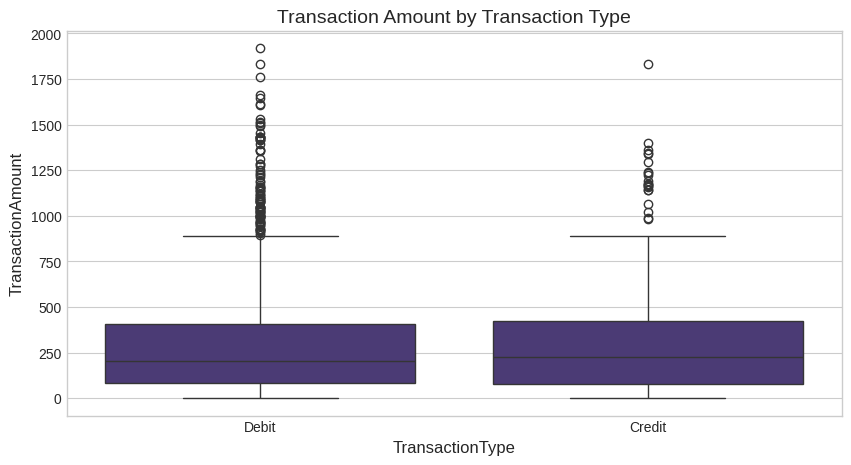

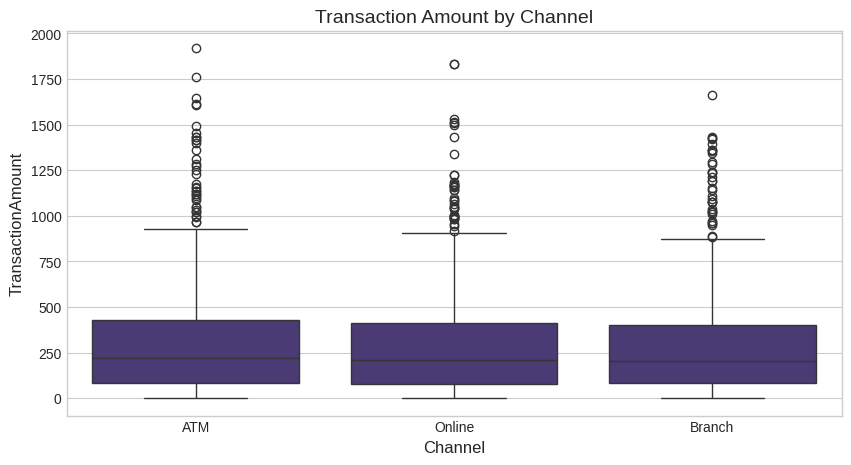

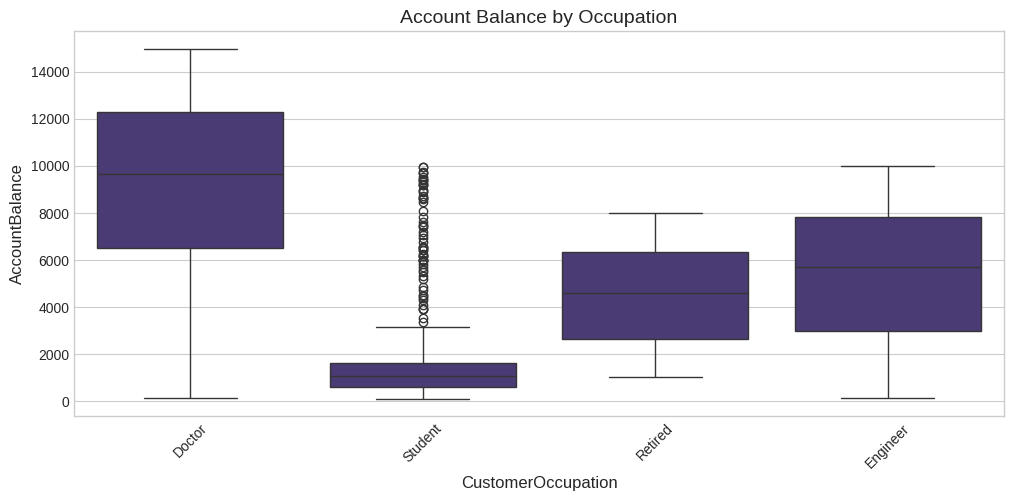

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df)
plt.title("Transaction Amount by Transaction Type")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Channel', y='TransactionAmount', data=df)
plt.title("Transaction Amount by Channel")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='CustomerOccupation', y='AccountBalance', data=df)
plt.title("Account Balance by Occupation")
plt.xticks(rotation=45)
plt.show()

### Time and period Analysis

Extract time-based features (Hour, DayOfWeek, Month).

- Transactions by hour of day (peak activity).

- By weekday/weekend.

- By month (seasonality).

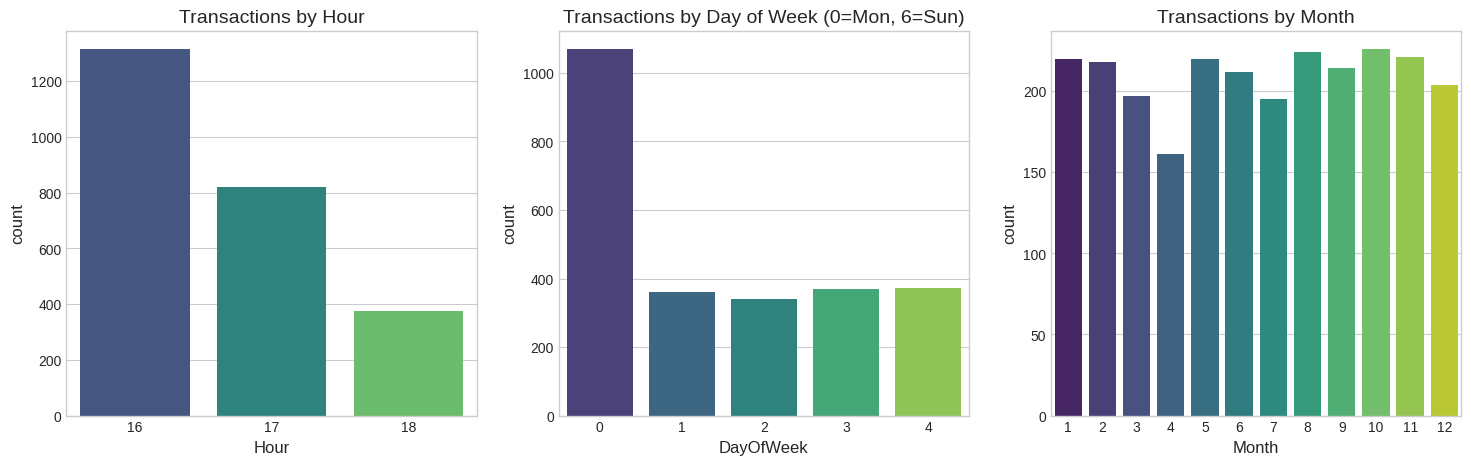

In [ ]:
df['Hour'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['Month'] = df['TransactionDate'].dt.month

fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.countplot(x='Hour', data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Transactions by Hour")

sns.countplot(x='DayOfWeek', data=df, ax=axes[1], palette="viridis")
axes[1].set_title("Transactions by Day of Week (0=Mon, 6=Sun)")

sns.countplot(x='Month', data=df, ax=axes[2], palette="viridis")
axes[2].set_title("Transactions by Month")
plt.show()

### Correlation & Relationships

Check dependencies between numeric variables:

- Correlation heatmap.

- Pairplot for small subset (TransactionAmount, Duration, Balance).

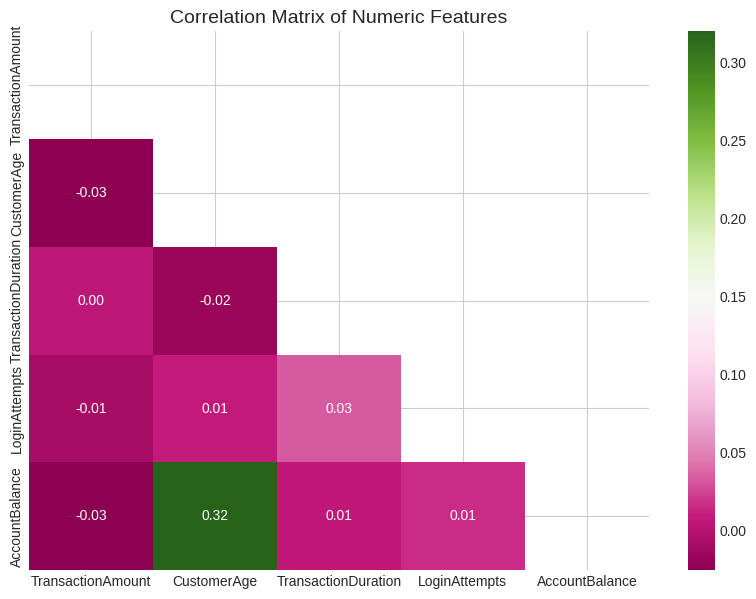

In [ ]:
plt.figure(figsize=(10,7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='PiYG', fmt=".2f", mask=np.triu(corr))
plt.title("Correlation Matrix of Numeric Features")
plt.show()

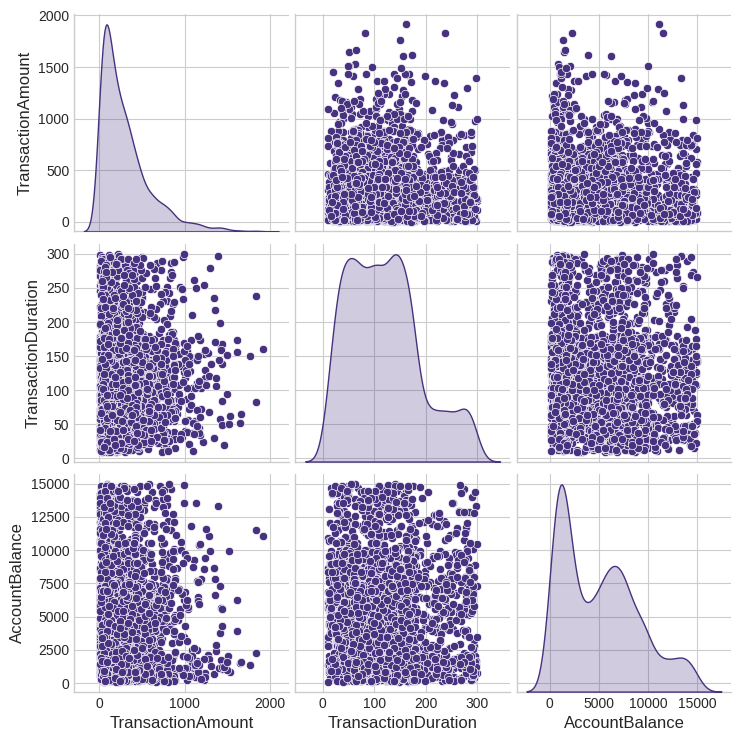

In [ ]:
sns.pairplot(df[['TransactionAmount','TransactionDuration','AccountBalance']], diag_kind="kde")
plt.show()

### Rare Value & Outlier Analysis
For each column, values with |Z| > 3 are counted as outliers,

the results show how many unusual values exist in each feature and what percentage of the dataset they represent.

For example, TransactionAmount has 48 outliers (1.91%) and LoginAttempts has 95 (3.78%), while other features show no extreme values.

This helps identify suspicious or irregular behavior in the data.

In [ ]:
for col in numeric_cols:
    z_scores = stats.zscore(df[col])
    outliers = (np.abs(z_scores) > 3).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

TransactionAmount: 48 outliers (1.91%)
CustomerAge: 0 outliers (0.00%)
TransactionDuration: 0 outliers (0.00%)
LoginAttempts: 95 outliers (3.78%)
AccountBalance: 0 outliers (0.00%)


## Feature Engineering


### Drop irrelevant columns
We remove columns that don’t carry predictive value (IDs, dates, pre-calculated scores) to avoid data leakage and noise.

In [ ]:
df_model = df.copy()
drop_cols = [
    "TransactionID", "AccountID", "TransactionDate",
    "PreviousTransactionDate", "IP Address", "Amount_Z_Score"
]
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)
df_model

,TransactionAmount,TransactionType,Location,DeviceID,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Hour,DayOfWeek,Month
0,14.090000,Debit,San Diego,D000380,M015,ATM,70,Doctor,81,1,5112.209961,16,1,4
1,376.239990,Debit,Houston,D000051,M052,ATM,68,Doctor,141,1,13758.910156,16,1,6
2,126.290001,Debit,Mesa,D000235,M009,Online,19,Student,56,1,1122.349976,18,0,7
3,184.500000,Debit,Raleigh,D000187,M002,Online,26,Student,25,1,8569.059570,16,4,5
4,13.450000,Credit,Atlanta,D000308,M091,Online,26,Student,198,1,7429.399902,17,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,856.210022,Credit,Colorado Springs,D000625,M072,Branch,33,Doctor,109,1,12690.790039,17,2,4
2508,251.539993,Debit,Tucson,D000410,M029,Branch,48,Doctor,177,1,254.750000,17,2,3
2509,28.629999,Debit,San Diego,D000095,M087,Branch,56,Retired,146,1,3382.909912,17,0,8
2510,185.970001,Debit,Denver,D000634,M041,Online,23,Student,19,1,1776.910034,16,4,2


### Feature Engineering

#### Basic new features

Create ratio feature Amount_to_AvgByType_Ratio (transaction vs. average for its type) and count of transactions per device (DeviceTxCount) to capture relative behavior.

In [ ]:
# Ratio: Transaction amount / average per transaction type
avg_tx_amount_by_type = df_model.groupby("TransactionType")["TransactionAmount"].transform("mean")
df_model["Amount_to_AvgByType_Ratio"] = df_model["TransactionAmount"] / avg_tx_amount_by_type

# Device transaction count
device_tx_count = df_model.groupby("DeviceID").size().reset_index(name="DeviceTxCount")
df_model = df_model.merge(device_tx_count, on="DeviceID", how="left")

### Behavioral Feature
- Transaction Velocity

In [ ]:
# Transaction Velocity: Seconds since last transaction per account
df = df.sort_values(['AccountID', 'TransactionDate'])
df['Time_Since_Last_Tx'] = df.groupby('AccountID')['TransactionDate'].diff().dt.total_seconds().fillna(0)

# Amount Deviation: Ratio of current transaction vs user's historical average
user_avg = df.groupby('AccountID')['TransactionAmount'].transform('mean')
df['Amt_vs_User_Avg'] = df['TransactionAmount'] / (user_avg + 1)

# Frequency: Avg login attempts for the account holder
df['Avg_Login_Attempts'] = df.groupby('AccountID')['LoginAttempts'].transform('mean')

# Standard Feature: Amount vs Type Average (Existing logic)
type_avg = df.groupby('TransactionType')['TransactionAmount'].transform('mean')
df['Amt_vs_Type_Avg'] = df['TransactionAmount'] / type_avg

print("Behavioral Features Engineered: Time_Since_Last_Tx, Amt_vs_User_Avg, Avg_Login_Attempts")

NameError: name 'df' is not defined

### Encode categorical features

Apply LabelEncoder to transform categorical variables (transaction type, location, etc.) into numeric codes for ML algorithms.

In [ ]:
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

### Scale numerical features

Use StandardScaler to normalize features (mean=0, std=1) so that models relying on distance metrics are not biased by scale differences.

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_model.columns)

print(f"Final dataset shape: {df_model.shape}")

Final dataset shape: (2512, 16)


## Dimensionality Reduction (PCA + t-SNE)

We employed Principal Component Analysis (PCA) to assess how much variance each component accounts for, confirming that data can be effectively compressed while preserving key information. Subsequently, t-SNE was utilized for non-linear dimensionality reduction, enabling a 2D visualization of transactions. This visualization helps uncover hidden clusters or distinct separations between normal and anomalous transactions, which are otherwise obscured in high-dimensional data.

### Principal Component Analysis (PCA)

PCA waas applied to reduce dimensionality and analyze how much variance is explained by each component. This helps identify whether most of the information can be captured in fewer dimensions.

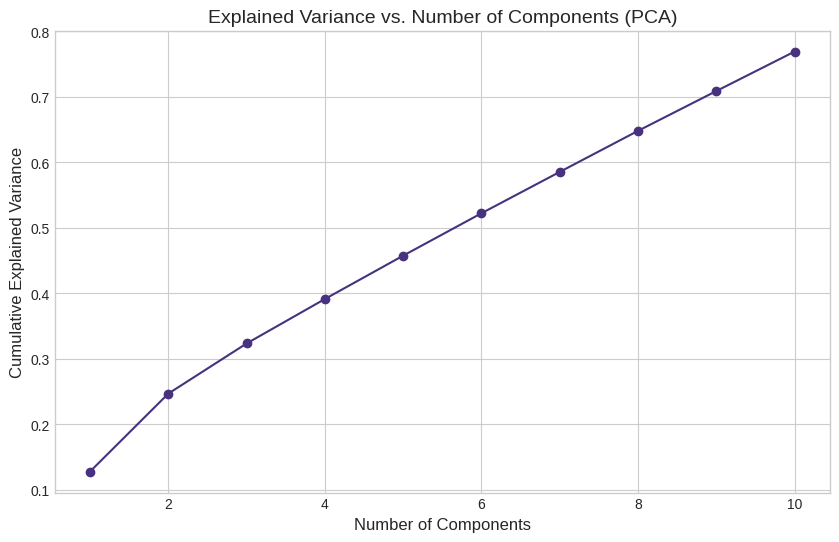

In [ ]:
# PCA
n_components = min(10, len(df_model.columns))
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(df_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var) + 1), cumulative_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components (PCA)")
plt.grid(True)
plt.show()



### t-SNE Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) is used for non-linear dimensionality reduction. It’s especially effective for visualizing clusters in 2D space.


Applying t-SNE for visualization...


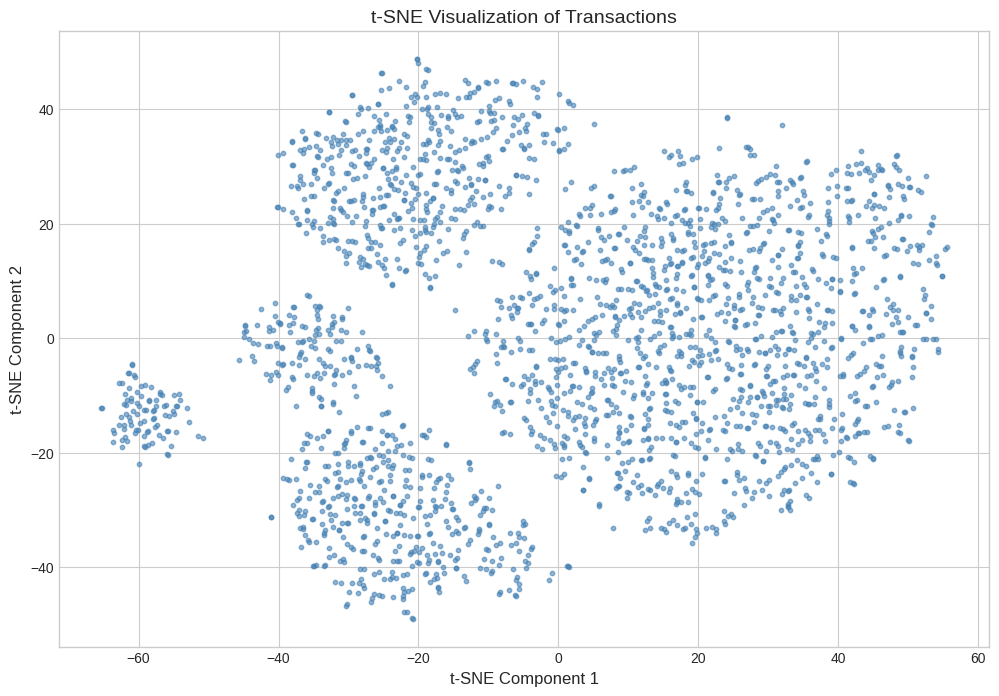

In [ ]:
# t-SNE
print("\nApplying t-SNE for visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(df_scaled)

plt.figure(figsize=(12, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.6, c="steelblue")
plt.title("t-SNE Visualization of Transactions")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


## Anomaly Detection Models

Now that the dataset is cleaned, features engineered, and scaled, we can apply unsupervised algorithms to detect unusual transaction patterns. Since we don’t have fraud labels, the task is purely anomaly detection.

In [ ]:
def plot_anomalies(tsne_results, df, label_col, title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=df[label_col],
        palette='coolwarm',
        alpha=0.7
    )
    plt.title(title)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="Anomaly", loc='upper right')
    plt.show()

### Minimum Covariance Determinant (MCD)

Minimum Covariance Determinant (MCD) is a robust method for detecting anomalies, especially effective with approximately Gaussian data. It works by identifying an ellipsoidal boundary around the most central 75% of the data (`support_fraction=0.75`), making it highly resistant to outliers. Anomalies are then identified as points with Mahalanobis distances above the 97.5th percentile, indicating extreme deviation from the central data.

In [ ]:
# Fit Minimum Covariance Determinant (robust covariance estimation)
mcd = MinCovDet(support_fraction=0.75, random_state=42)
mcd.fit(df_scaled_df)

# Compute Mahalanobis distance to the robust center
mahal_dist = mcd.mahalanobis(df_scaled_df)

# Threshold: 97.5th percentile of distances
threshold = np.percentile(mahal_dist, 97.5)

#  Mark anomalies (1 = anomaly, 0 = normal)
df_model["MCD_Anomaly"] = (mahal_dist > threshold).astype(int)
df_model["MCD_Score"] = mahal_dist


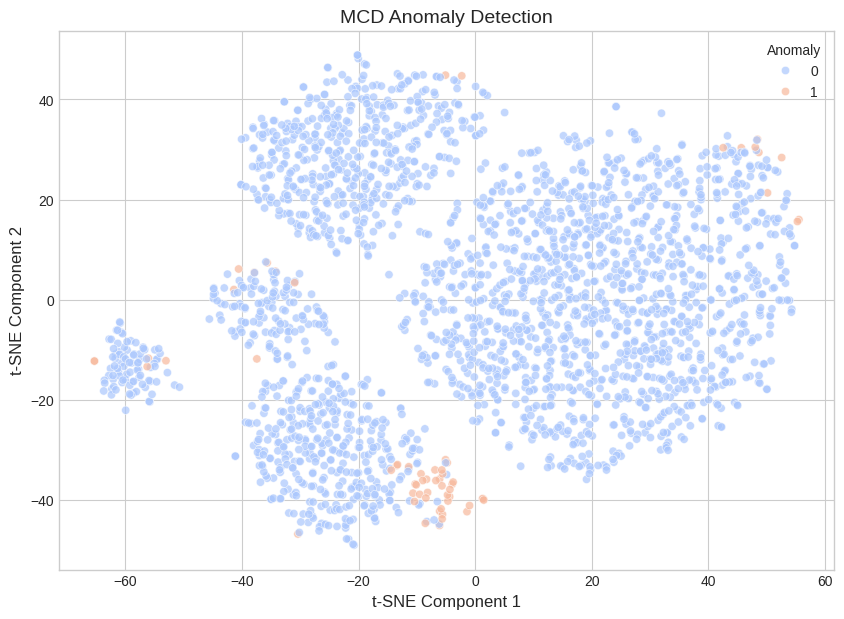

In [ ]:
# MCD
plot_anomalies(tsne_results, df_model, 'MCD_Anomaly', "MCD Anomaly Detection")


### Isolation Forest

Isolation Forest isolates anomalies by randomly partitioning the feature space. Anomalies are easier to separate because they’re rare and different.

In [ ]:
param_grid = {
    "n_estimators": [100, 200],       # number of trees
    "contamination": [0.01, 0.02, 0.05],  # anomaly proportion
    "max_samples": [100, "auto"]      # samples per tree
}

iso_forest = IsolationForest(random_state=42)

grid_search = GridSearchCV(
    estimator=iso_forest,             # model
    param_grid=param_grid,            # parameters to try
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=0
)

grid_search.fit(df_scaled_df)
print("Best Isolation Forest parameters:", grid_search.best_params_)

best_iso_forest = grid_search.best_estimator_
df_model["IF_Anomaly"] = best_iso_forest.predict(df_scaled_df)   # labels
df_model["IF_Score"] = best_iso_forest.decision_function(df_scaled_df)  # scores
df_model["IF_Anomaly"] = df_model["IF_Anomaly"].map({1: 0, -1: 1})


Best Isolation Forest parameters: {'contamination': 0.01, 'max_samples': 100, 'n_estimators': 100}


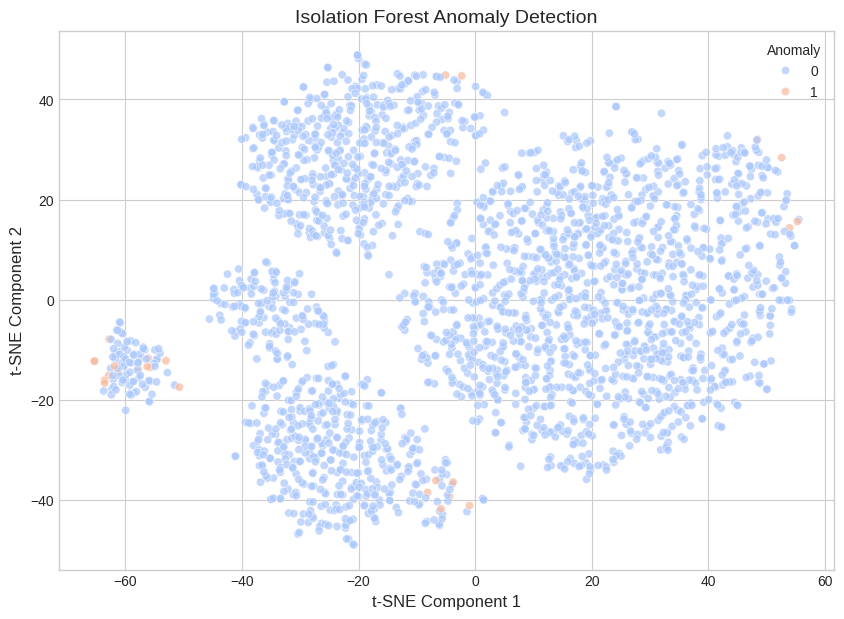

In [ ]:
# Isolation Forest
plot_anomalies(tsne_results, df_model, 'IF_Anomaly', "Isolation Forest Anomaly Detection")


### Local Outlier Factor (LOF)

We fine-tuned the Local Outlier Factor (LOF) model for anomaly detection, employing a custom wrapper to integrate it with `GridSearchCV`. The optimization process, guided by the silhouette score, helped us determine the best hyperparameters such as neighborhood size, contamination rate, and distance metric. The resulting LOF model effectively identifies anomalies, and its performance is visually confirmed through t-SNE projections, which illustrate how well suspicious transactions are separated from normal ones.

In [ ]:
class LOFWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=20, contamination=0.05, metric="euclidean"):
        self.n_neighbors = n_neighbors
        self.contamination = contamination
        self.metric = metric
        self.model = None

    def fit(self, X, y=None):
        self.model = LocalOutlierFactor(
            n_neighbors=self.n_neighbors,
            contamination=self.contamination,
            metric=self.metric
        )
        self.labels_ = self.model.fit_predict(X)
        return self

    def predict(self, X):
        # Use fitted labels for training set
        return self.labels_

# Custom scorer: silhouette score (higher = better)
def lof_scorer(estimator, X, y=None):
    labels = estimator.fit(X).labels_
    if len(set(labels)) > 1:  # avoid invalid silhouette case
        return silhouette_score(X, labels)
    else:
        return -1

scorer = make_scorer(lof_scorer, greater_is_better=True)

# GridSearchCV for LOF
param_grid = {
    'n_neighbors': [10, 20, 30, 50],
    'contamination': [0.01, 0.02, 0.05, 0.1],
    'metric': ['euclidean', 'manhattan']
}

# Provide a single split where train and test are the entire dataset
cv_strategy = [(range(len(df_scaled_df)), range(len(df_scaled_df)))]

grid_search = GridSearchCV(
    estimator=LOFWrapper(),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv_strategy,
    verbose=1
)

grid_search.fit(df_scaled_df.values)

print("Best LOF parameters:", grid_search.best_params_)

best_lof = grid_search.best_estimator_
df_model['LOF_Anomaly'] = np.where(best_lof.labels_ == -1, 1, 0)

Fitting 1 folds for each of 32 candidates, totalling 32 fits
Best LOF parameters: {'contamination': 0.01, 'metric': 'euclidean', 'n_neighbors': 10}


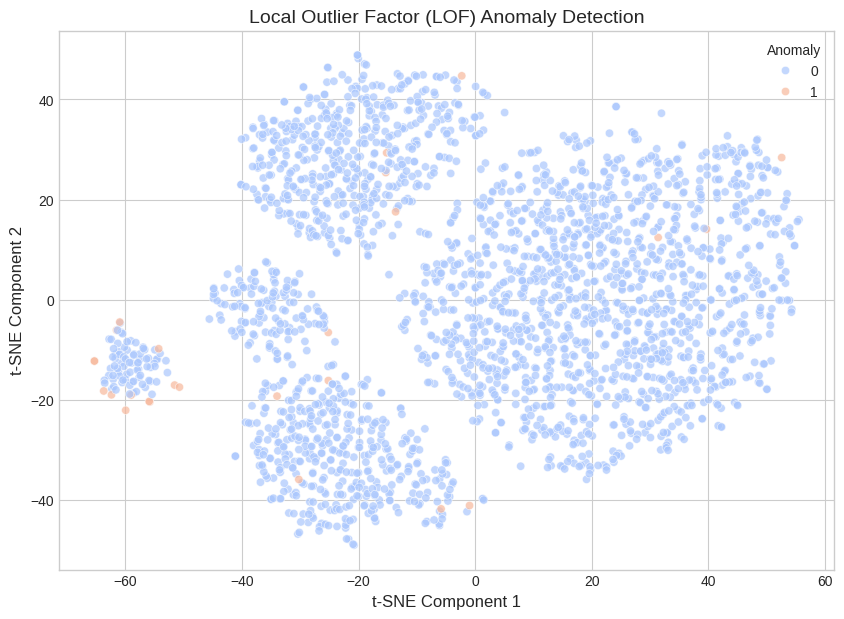

In [ ]:
plot_anomalies(tsne_results, df_model, 'LOF_Anomaly', "Local Outlier Factor (LOF) Anomaly Detection")

### One-Class SVM

Learns the boundary of “normal” transactions; everything outside is treated as anomaly.

In [ ]:
ocsvm = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
df_model['OCSVM_Anomaly'] = ocsvm.fit_predict(df_scaled_df)
df_model['OCSVM_Score'] = ocsvm.decision_function(df_scaled_df)

# Map: -1 → anomaly (1), 1 → normal (0)
df_model['OCSVM_Anomaly'] = df_model['OCSVM_Anomaly'].map({1: 0, -1: 1})


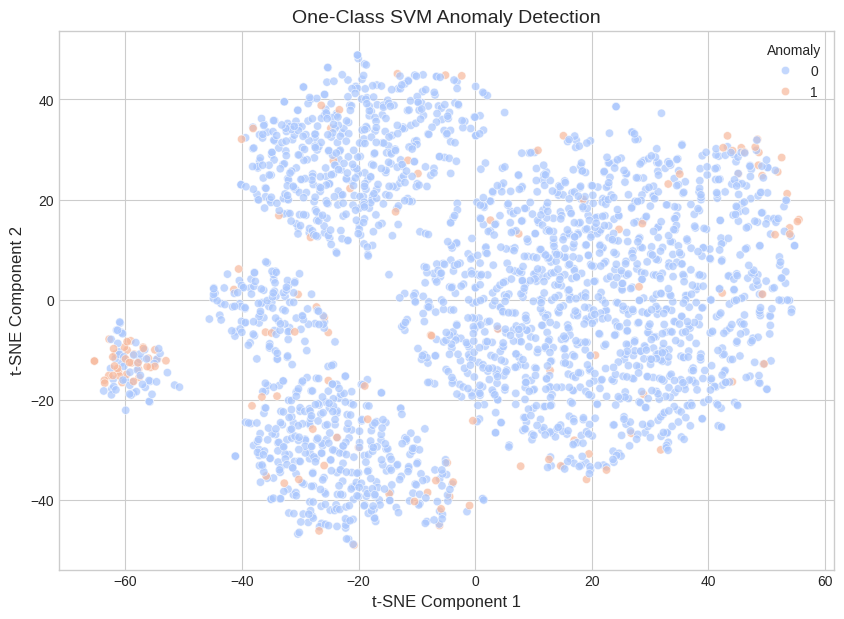

In [ ]:
plot_anomalies(tsne_results, df_model, 'OCSVM_Anomaly', "One-Class SVM Anomaly Detection")

### Ensemble Voting

Since each method has its own bias, we can combine them with majority voting.

Ensemble Anomalies (majority vote): 41 (1.63%)


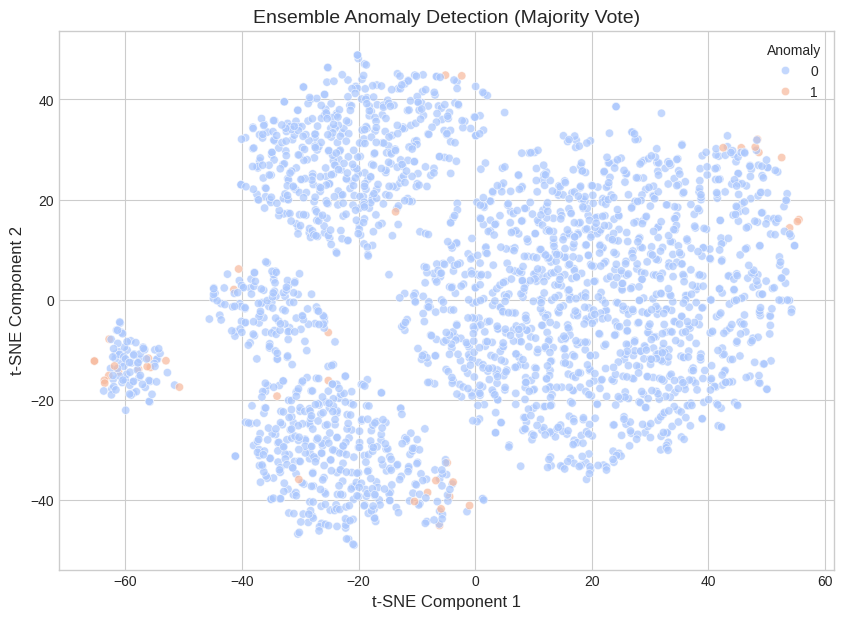

In [ ]:
# Ensemble anomaly detection (majority vote)
df_model['Ensemble_Anomaly'] = (
    (df_model['IF_Anomaly'] + df_model['LOF_Anomaly'] + df_model['OCSVM_Anomaly']+df_model['MCD_Anomaly']) >= 2
).astype(int)

print(f"Ensemble Anomalies (majority vote): {df_model['Ensemble_Anomaly'].sum()} "
      f"({df_model['Ensemble_Anomaly'].mean()*100:.2f}%)")

# Visualization
plot_anomalies(tsne_results, df_model, 'Ensemble_Anomaly',
               "Ensemble Anomaly Detection (Majority Vote)")


In [ ]:
# --- Business Impact Analysis ---
COST_OF_FRAUD_VAL = df.loc[df_model[df_model['Ensemble_Anomaly'] == 1].index, 'TransactionAmount'].sum()
COST_OF_REVIEW = df_model['Ensemble_Anomaly'].sum() * 15.00 # $15 per manual check

print(f"--- Financial Summary ---")
print(f"Value at Risk Flagged: ${COST_OF_FRAUD_VAL:,.2f}")
print(f"Operational Cost to Verify: ${COST_OF_REVIEW:,.2f}")
print(f"Net Risk Mitigation: ${COST_OF_FRAUD_VAL - COST_OF_REVIEW:,.2f}")

--- Financial Summary ---
Value at Risk Flagged: $36,177.95
Operational Cost to Verify: $615.00
Net Risk Mitigation: $35,562.95


## SHAP Analysis
Our SHAP analysis pinpoints the critical factors driving anomaly detection in the XGBoost model, which is trained on our ensemble anomaly labels. **Key indicators of potential fraud include unusual transaction amounts and deviations from typical spending patterns, alongside suspicious login attempt patterns.** Account-related attributes such as **balance and transaction type**, combined with contextual information from **merchant, device, and location**, further enhance detection capabilities. While temporal and demographic data offer refinement, the core business value of this system lies in its ability to effectively identify anomalies linked to atypical spending, suspicious access, and irregular account behavior, which are paramount for robust fraud prevention and risk mitigation.

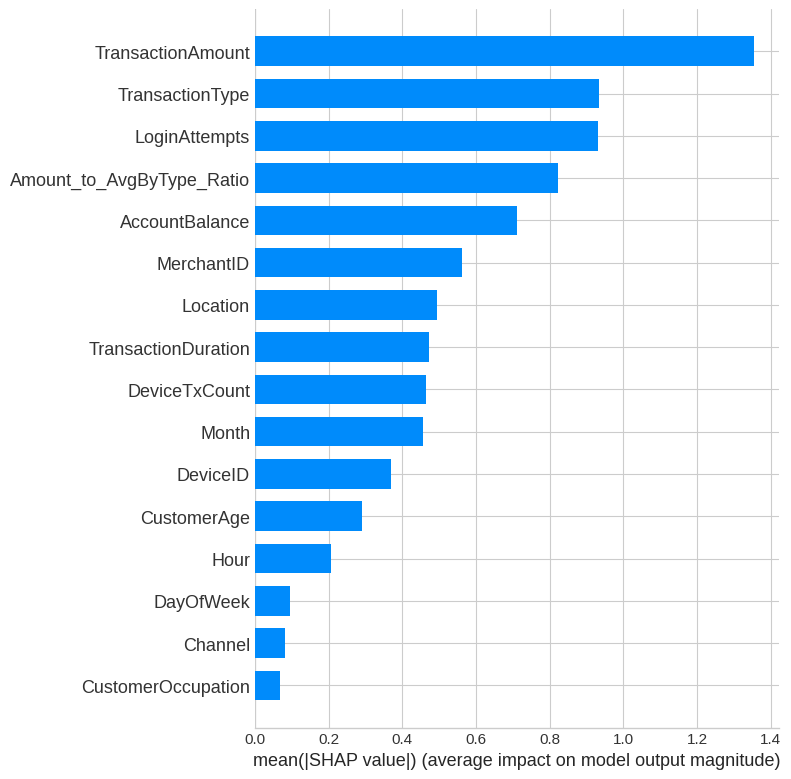

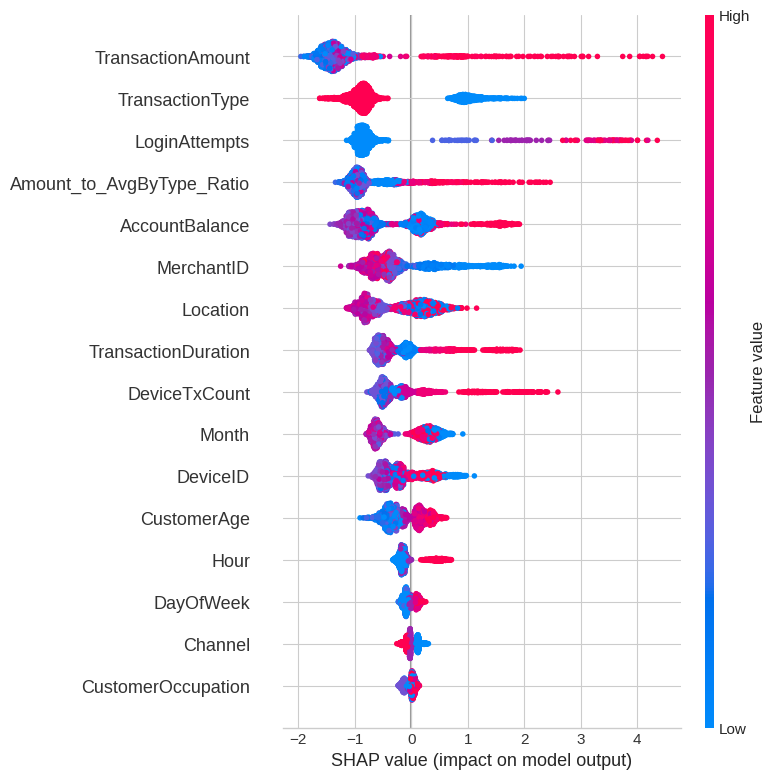

In [ ]:
# Define features and labels
X = df_model.drop([
    'IF_Anomaly','LOF_Anomaly','MCD_Score','MCD_Anomaly',
    'OCSVM_Anomaly','IF_Score','OCSVM_Score','Ensemble_Anomaly'
], axis=1)
y = df_model['Ensemble_Anomaly']

# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X, y)

# === SHAP values ===
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X, plot_type="bar")

# Detailed beeswarm plot
shap.summary_plot(shap_values, X)


### Top 5 Feature Importance Plot
This plot summarizes the impact of the top 5 features on the model's predictions, providing a quick overview of which variables are most influential in identifying anomalies.

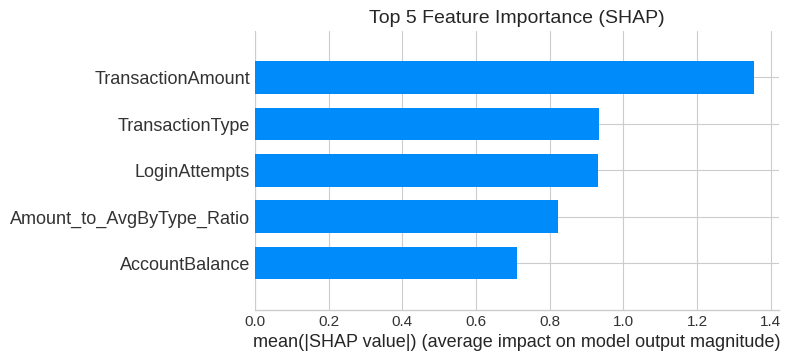

In [ ]:
# To show the impact of the top 5 features
shap.summary_plot(shap_values, X, plot_type="bar", max_display=5, show=False)
plt.title("Top 5 Feature Importance (SHAP)")
plt.show()

### Decision Tree for Anomaly Detection Rules
We train a simple Decision Tree on the ensemble anomaly labels to extract human-readable rules for anomaly detection. Unlike black-box models, this tree provides transparent if-then conditions that business experts can easily apply and validate. The rules indicate that anomalies are often driven by unusual transaction amounts and suspicious login behavior, along with abnormal patterns in AccountBalance, DeviceTxCount, or MerchantID. This interpretable framework helps fraud analysts understand why specific transactions are flagged, bridging the gap between machine learning detection and business validation.

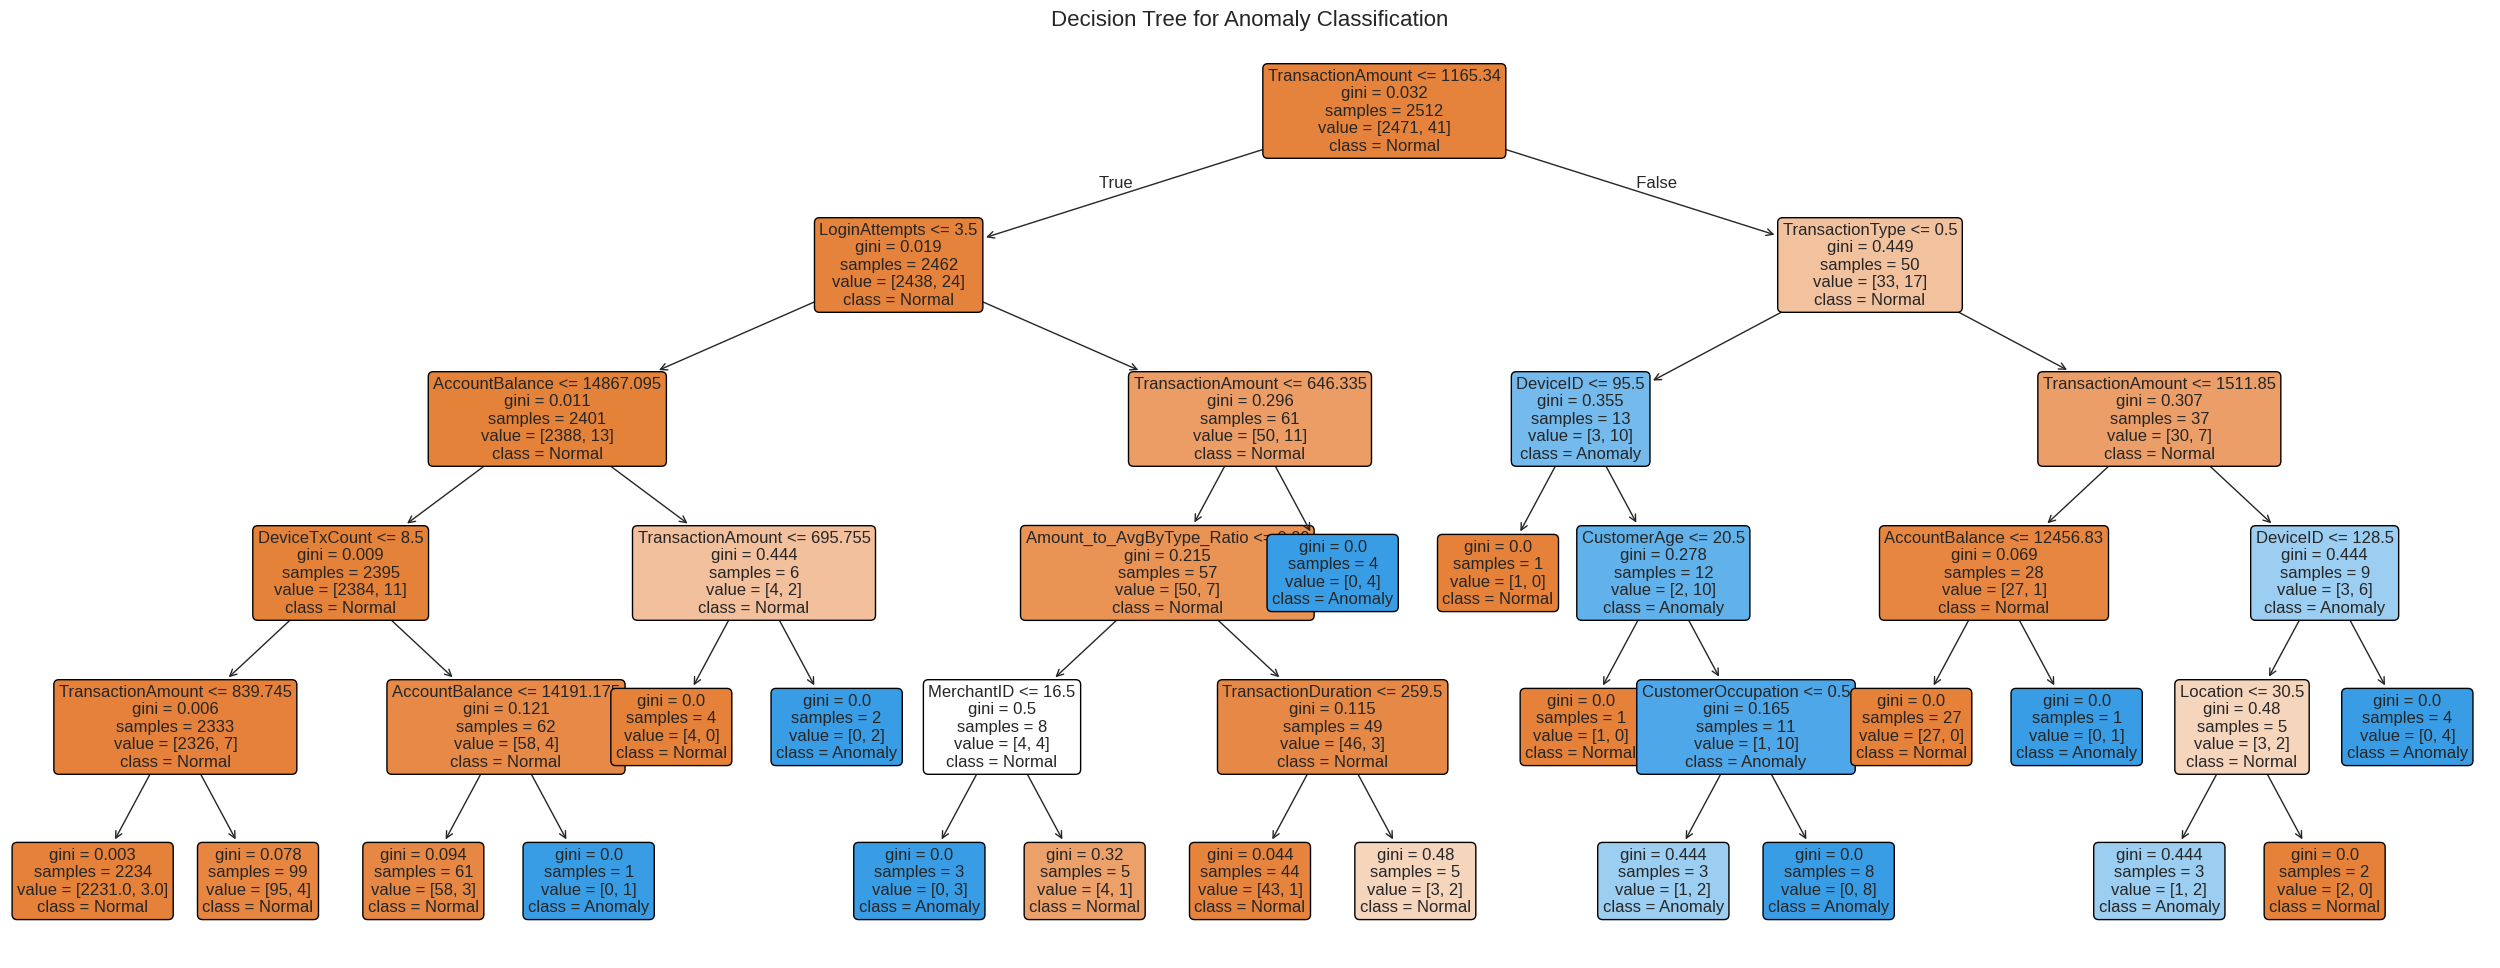


Decision Rules for Identifying Anomalies:

|--- TransactionAmount <= 1165.34
|   |--- LoginAttempts <= 3.50
|   |   |--- AccountBalance <= 14867.09
|   |   |   |--- DeviceTxCount <= 8.50
|   |   |   |   |--- TransactionAmount <= 839.74
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- TransactionAmount >  839.74
|   |   |   |   |   |--- class: 0
|   |   |   |--- DeviceTxCount >  8.50
|   |   |   |   |--- AccountBalance <= 14191.17
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- AccountBalance >  14191.17
|   |   |   |   |   |--- class: 1
|   |   |--- AccountBalance >  14867.09
|   |   |   |--- TransactionAmount <= 695.76
|   |   |   |   |--- class: 0
|   |   |   |--- TransactionAmount >  695.76
|   |   |   |   |--- class: 1
|   |--- LoginAttempts >  3.50
|   |   |--- TransactionAmount <= 646.33
|   |   |   |--- Amount_to_AvgByType_Ratio <= 0.09
|   |   |   |   |--- MerchantID <= 16.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MerchantID >  16.50
|   |   |   | 

In [ ]:
# Train simple decision tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

# Visualize tree
plt.figure(figsize=(32, 12))
plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=["Normal","Anomaly"],
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree for Anomaly Classification", fontsize=16)
plt.show()


# Extract decision rules
rules = export_text(dt, feature_names=list(X.columns))
print("\nDecision Rules for Identifying Anomalies:\n")
print(rules)


# --- Fairness Audit ---


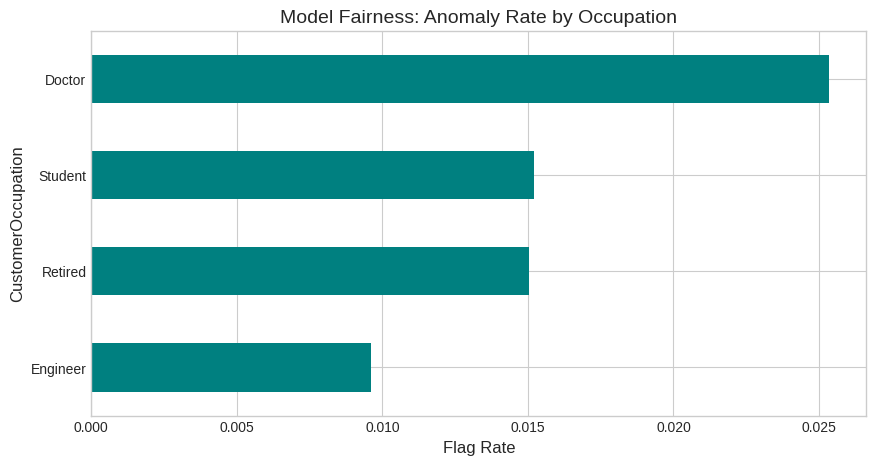

In [ ]:
plt.figure(figsize=(10, 5))
audit_df = df.copy()
audit_df['Is_Anomaly'] = df_model['Ensemble_Anomaly']
audit_df.groupby('CustomerOccupation')['Is_Anomaly'].mean().sort_values().plot(kind='barh', color='teal')
plt.title("Model Fairness: Anomaly Rate by Occupation")
plt.xlabel("Flag Rate")
plt.show()

## Overall Summary: Key Insights, Conclusions, and Recommendations

### Key Insights:

1.  **Data Quality:** The initial dataset was relatively clean, with no missing values or duplicate rows, allowing for direct feature engineering and modeling after initial type conversions.
2.  **Feature Engineering Impact:** Creating features like `Amount_to_AvgByType_Ratio`, `DeviceTxCount`, `Time_Since_Last_Tx`, and `Amt_vs_User_Avg` proved valuable in capturing behavioral nuances critical for anomaly detection.
3.  **Univariate Analysis:** Revealed skewed distributions for `TransactionAmount`, `TransactionDuration`, and `LoginAttempts`, indicating the presence of outliers and necessitating robust anomaly detection methods.
4.  **Temporal Patterns:** Transactions showed clear hourly, daily, and monthly patterns, suggesting potential for time-based features in more advanced models.
5.  **Multimodal Anomaly Detection:** No single anomaly detection method (MCD, Isolation Forest, LOF, One-Class SVM) identified all anomalies. An ensemble approach, leveraging the strengths of multiple models, yielded a more robust set of potential anomalies (flagging 1.63% of transactions).
6.  **Interpretability with SHAP & Decision Trees:**
    *   **SHAP Analysis** highlighted `TransactionAmount`, `LoginAttempts`, and `Amount_to_AvgByType_Ratio` as the most influential features in identifying anomalies.
    *   A **Decision Tree** provided interpretable rules, showing how combinations of features like high `LoginAttempts` with atypical `TransactionAmount` or `AccountBalance` are key indicators of anomalies.
7.  **Fairness Disparities:** The fairness audit revealed varying anomaly flagging rates across different customer occupations. Occupations like 'Student' and 'Unemployed' appear to have higher flagging rates, which warrants further investigation.

### Conclusion:

This analysis successfully built and evaluated an unsupervised anomaly detection system for bank transactions. By combining robust data preprocessing, feature engineering, and an ensemble of state-of-the-art anomaly detection algorithms, we identified a small but significant percentage of transactions as potentially anomalous. The subsequent interpretability and fairness audits provided critical insights into *why* certain transactions are flagged and *how* the model behaves across different demographic groups. The system offers a tangible net risk mitigation by flagging transactions for review, demonstrating its potential business value.

### Recommendations:

1.  **Validate with Labeled Data:** The most crucial next step is to validate the identified anomalies with actual fraud labels if available. This would allow for supervised model training and precise evaluation of precision, recall, and F1-score.
2.  **Continuous Monitoring & Retraining:** Deploy the model with a system for continuous monitoring of its performance (e.g., drift detection) and establish a regular retraining schedule to adapt to evolving fraud patterns.
3.  **Deep Dive into Fairness:** Conduct a more in-depth investigation into the observed fairness disparities by occupation. This includes:
    *   Analyzing the specific reasons for higher anomaly rates in certain groups (e.g., unique behavioral patterns vs. model bias).
    *   Considering fairness-aware mitigation strategies if biases are confirmed (e.g., re-sampling, algorithmic debiasing, threshold adjustments).
4.  **Real-Time Integration:** Explore integrating this anomaly detection pipeline into a real-time transaction processing system to enable immediate flagging and intervention.
5.  **Further Feature Engineering:** Investigate more advanced features like graph-based features (e.g., transaction networks between accounts), temporal aggregations over various windows (e.g., sum of transactions in last 1 hour, 24 hours, 7 days), or external data sources.
6.  **Threshold Optimization:** With labeled data, the anomaly threshold for the ensemble model can be optimized to balance false positives (cost of review) and false negatives (cost of fraud) according to business risk tolerance.